In [ ]:
!pip install diffusers transformers accelerate --upgrade

In [2]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

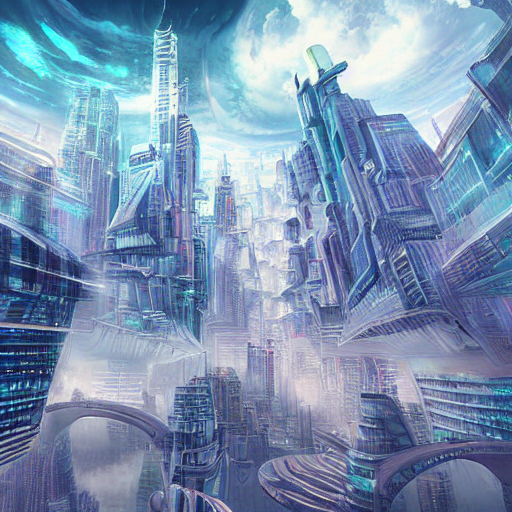

In [3]:
prompt = "A surreal futuristic city in the clouds, digital art"
image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
image.save("output.png")
image


  0%|          | 0/40 [00:00<?, ?it/s]

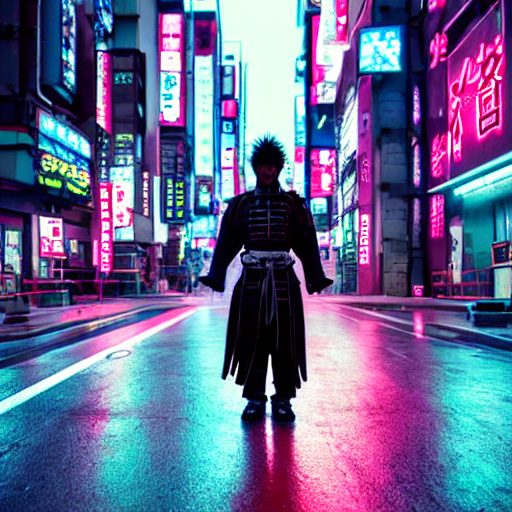

In [4]:
prompt = "Cyberpunk samurai in a neon-lit Tokyo street, cinematic style"

image = pipe(
    prompt,
    num_inference_steps=40,    # Menor pasos = más rápido, pero menos calidad
    guidance_scale=8.0         # Más alto = más fiel al prompt, pero menos creatividad
).images[0]

image.save("cyberpunk_samurai.png")
image


In [5]:
styles = ["oil painting", "cyberpunk", "photorealistic", "low poly", "watercolor"]
base_prompt = "A lonely astronaut on an alien planet"

images = []
for style in styles:
    styled_prompt = f"{base_prompt}, {style}"
    img = pipe(styled_prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
    images.append(img)


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

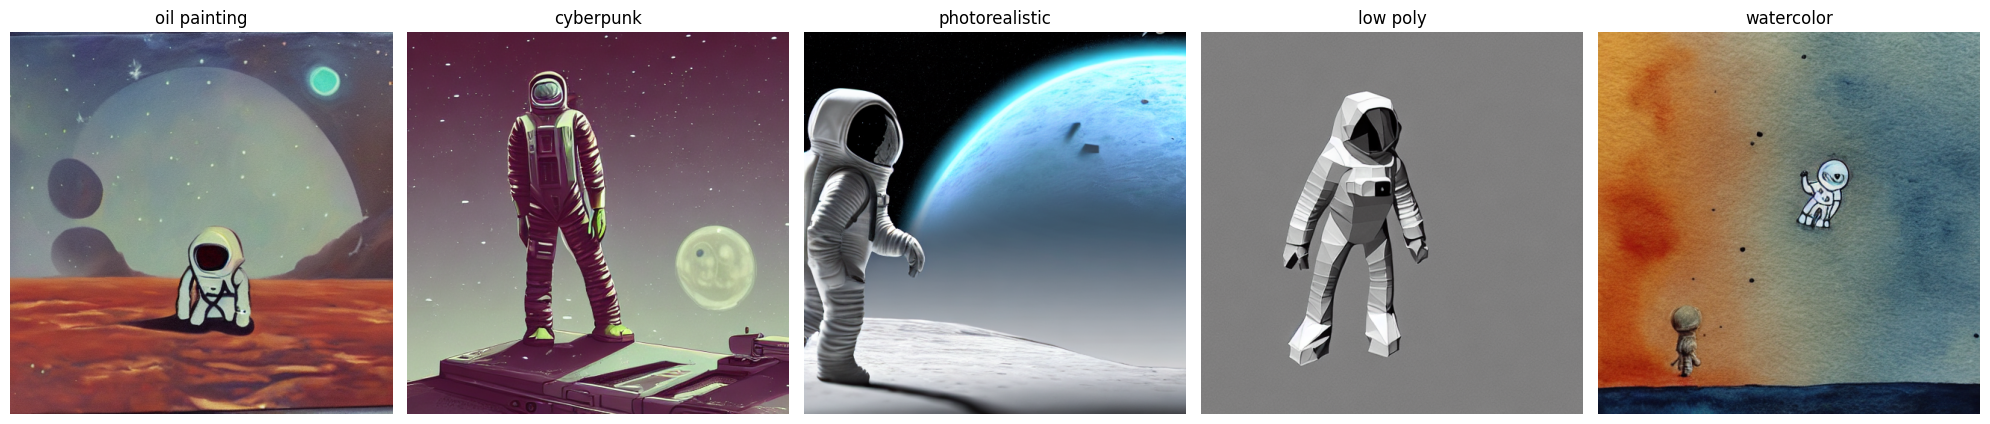

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, len(images), figsize=(20, 5))
for i, img in enumerate(images):
    axs[i].imshow(img)
    axs[i].axis("off")
    axs[i].set_title(styles[i])
plt.tight_layout()
plt.show()
